In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, json
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

## Repeatable Figure Generation and XAP Clustering Analysis

#### Create mean embeddings

In [29]:
# load data here as mlp
mlp = ad.read_h5ad('/scratch/users/samutiti/U54/SubCellNuc/training_V08/inference_U2OS.h5ad')
print(mlp)

AnnData object with n_obs × n_vars = 293106 × 1280
    obs: 'gene_name', 'gene_idx', 'locations', 'atlas_name'
    obsm: 'h'


In [14]:
def mean_embeddings_by_gene_with_loc(embeddings: np.ndarray, df: pd.DataFrame):
    """
    Compute mean embedding per gene_name and return the first localization.

    Parameters
    ----------
    embeddings : np.ndarray
        Shape (N, D)
    df : pd.DataFrame
        Must contain columns:
            - 'gene_names'
            - 'locations'

    Returns
    -------
    gene_means : np.ndarray
        Shape (G, D)
    unique_genes : np.ndarray
        Gene names aligned to gene_means
    gene_localizations : np.ndarray
        First localization per gene, aligned to gene_means
    """

    if len(embeddings) != len(df):
        raise ValueError("Embeddings and dataframe must have the same number of rows.")

    # Extract first localization (before comma) efficiently
    first_locs = df["locations"].str.split(",").str[0].values

    # Factorize genes (preserves order of first appearance)
    labels, unique_genes = pd.factorize(df["gene_name"])
    n_genes = len(unique_genes)

    # Sum embeddings per gene
    gene_sums = np.zeros((n_genes, embeddings.shape[1]), dtype=np.float32)
    np.add.at(gene_sums, labels, embeddings)

    # Count per gene
    counts = np.bincount(labels).reshape(-1, 1)

    gene_means = gene_sums / counts

    # Get first localization per gene (aligned to factorization order)
    first_loc_per_gene = pd.Series(first_locs).groupby(labels).first().values
    data_df = pd.DataFrame({
        'gene': unique_genes,
        'loc': first_loc_per_gene
    })

    return gene_means, data_df

In [15]:
def make_mean_df(adata):
    df = adata.obs
    embeddings = adata.X
    df_expanded = df.assign(gene_names=df["gene_name"].str.split(",")).explode("gene_name")
    # embeddings_expanded = np.repeat(embeddings, df["gene_name"].str.count(",") + 1, axis=0)
    embeddings_expanded = embeddings

    gene_means, data_df = mean_embeddings_by_gene_with_loc(embeddings_expanded, df_expanded)
    new_adata = ad.AnnData(X=gene_means, obs=data_df)
    return new_adata

In [30]:
mean_mlpv8_u2OS = make_mean_df(mlp)
print(mean_mlpv8_u2OS)

AnnData object with n_obs × n_vars = 11273 × 1280
    obs: 'gene', 'loc'


/share/software/user/open/python/3.12.1/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### Load Data and Visualize

In [55]:
# specifically subcell data
esm = torch.load('/scratch/users/samutiti/U54/esm_data.pth', weights_only=False)

In [56]:
print(esm[0])
print(esm[1])
print(len(esm))
sc_ad = ad.AnnData(X=np.array(esm[0]), obs=esm[1])
sc_ad.write_h5ad('/scratch/users/samutiti/U54/data/esm_emb.adata')

[[ 0.04512023 -0.15134487 -0.02590631 ... -0.19875236  0.02393334
   0.22122625]
 [-0.00065003 -0.10517012  0.09406978 ... -0.05005169  0.00078166
   0.07325457]
 [ 0.04001711 -0.05627449 -0.02038135 ... -0.100129    0.08514756
   0.03282504]
 ...
 [ 0.04760703 -0.03175245 -0.02737919 ... -0.10360324 -0.04623744
   0.04211567]
 [-0.00125044 -0.02981432  0.02796889 ... -0.06135211  0.06863355
  -0.00617516]
 [ 0.05689012 -0.09434482  0.03174587 ... -0.01887236 -0.01794837
   0.13603698]]
         gene
0      Q9UH92
1      O43292
2      P56975
3      Q7Z601
4      A6NIK2
...       ...
21168  P0A7Q1
21169  Q6R2W3
21170  P25092
21171  O60682
21172  Q5JRK9

[21173 rows x 1 columns]
2


/share/software/user/open/python/3.12.1/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


##### load data

In [71]:
version = 1
load_dir = f'/scratch/users/samutiti/U54/SubCellNuc/training_V0{version}'
load_file = 'esm_mean_inference_analyzed.h5ad'

In [72]:
# load mlp
mlp_data = ad.read_h5ad(f'{load_dir}/{load_file}')
print(mlp_data)

AnnData object with n_obs × n_vars = 21173 × 1280
    obs: 'gene', 'leiden_0.3', 'umap_x', 'umap_y'
    uns: 'leiden_0.3', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


#### Add XAP and Disease labels

In [73]:
### Color By XAP
# Normalize function
def normalize_gene(g):
    return g.replace("-", "").replace("_", "").strip().upper()

# Build a normalized lookup set once
xap_set_normalized = {normalize_gene(g) for g in {
"HMGB1", "ILF2", "XRN2", "POLDIP3", "RNF20", "FUBP3", "HNRPLL", "ILF3",
"SSB", "SRRT", "EIF4A3", "RNMT", "PTBP2", "SAP18", "WTAP", "KHDRBS1",
"ERH", "CIZ1", "HNRNPH3", "SYNCRIP", "NONO", "FUS", "DHX9", "RALY",
"DDX17", "HNRPDL", "KHSRP", "RNF2", "HNRNPA3", "HNRNPUL2", "HNRNPD",
"DDX5", "DDX39B", "PTBP1", "HNRNPR", "ZFR", "ELAVL1", "SRSF2",
"HNRNPM", "RBMXL1", "TARDBP", "MYEF2", "HNRNPU", "HNRNPC",
"HNRNPL", "HNRNPAB", "HNRNPK", "HNRNPA2B1", "HNRNPA1",
"HNRNPA0", "RBM14", "TRA2B", "SFPQ", "IGF2BP1", "SARNP",
"SRSF3", "MATR3", "SRSF5", "SPEN", "RBM15", "RBM3",
"SRSF7", "RBFOX2", "SRSF9", "SAFB", "THOC4", "DDX39A",
"CELF1", "PCGF5", "RYBP", "TRIM71", "SRSF10", "RBM4",
"YTHDC1", "TRIM6", "LIN28A", "SLTM", "SAFB2", "L1TD1",
"MYBBP1A", "IGF2BP3"
}}

def is_xap(genes):
    genes = genes.replace(' ', '').split(',')
    for gene in genes:
        if normalize_gene(gene) in xap_set_normalized:
            return 'XAPs'
    return 'Other Proteins' 

# USE if acc ids instead of gene names
with open('xap_to_accession_mapping.json', 'r') as f:
    xap_acc_list = json.load(f)
xap_acc_list_values = list(xap_acc_list.values())

def is_xap_acc(gene):
    if gene in xap_acc_list_values:
        return "XAPs"
    return "Other Proteins"

mlp_data.obs['XAP'] = [is_xap_acc(g) for g in mlp_data.obs['gene']]
# xaps = [is_xap(g) for g in mlp_data.obs['gene']] # these should be atlas names
# mlp_data.obs['XAP'] = xaps
if len(np.unique(mlp_data.obs['XAP'])) < 2:
    raise ValueError('XAPs not properly assigned')
mlp_data.write_h5ad(f'{load_dir}/{load_file}')
print(mlp_data)

AnnData object with n_obs × n_vars = 21173 × 1280
    obs: 'gene', 'leiden_0.3', 'umap_x', 'umap_y', 'XAP'
    uns: 'leiden_0.3', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


Map disease relevance

In [74]:
with open('/scratch/users/samutiti/U54/data/autoantigen_disease_mapping_v2.json', 'r') as f:
    disease_dict = json.load(f)
def map_to_disease(gene):
    try: return disease_dict[gene]
    except: return 'none'

diseases = [map_to_disease(gene) for gene in mlp_data.obs['gene']]
mlp_data.obs['disease'] = diseases
if len(np.unique(mlp_data.obs['disease'])) < 2:
    raise ValueError('disease labels not properly assigned')
mlp_data.write_h5ad(f'{load_dir}/{load_file}')
print(mlp_data)

AnnData object with n_obs × n_vars = 21173 × 1280
    obs: 'gene', 'leiden_0.3', 'umap_x', 'umap_y', 'XAP', 'disease'
    uns: 'leiden_0.3', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


#### Visualize

In [ ]:
mlp_df = mlp_data.obs
dataframe = mlp_df
print(dataframe.columns)
# print(dataframe)
# dataframe = dataframe.sort_values(by='loc')

Index(['gene', 'leiden_0.3', 'umap_x', 'umap_y', 'XAP', 'disease'], dtype='object')
7305                                             all three
1662                                             all three
11829                                            all three
10337                                      dermatomyositis
236                                        dermatomyositis
                               ...                        
8618                                    systemic sclerosis
16240                                   systemic sclerosis
17883    systemic sclerosis & systemic lupus erythematosus
10997    systemic sclerosis & systemic lupus erythematosus
19660    systemic sclerosis & systemic lupus erythematosus
Name: disease, Length: 21173, dtype: category
Categories (7, object): ['all three', 'dermatomyositis', 'dermatomyositis & systemic sclerosis', 'none', 'systemic lupus erythematosus', 'systemic sclerosis', 'systemic sclerosis & systemic lupus erythemat...]


7305     Other Proteins
30       Other Proteins
31       Other Proteins
32       Other Proteins
33       Other Proteins
              ...      
8512               XAPs
8044               XAPs
13381              XAPs
20478              XAPs
11067              XAPs
Name: XAP, Length: 21173, dtype: category
Categories (2, object): ['Other Proteins', 'XAPs']


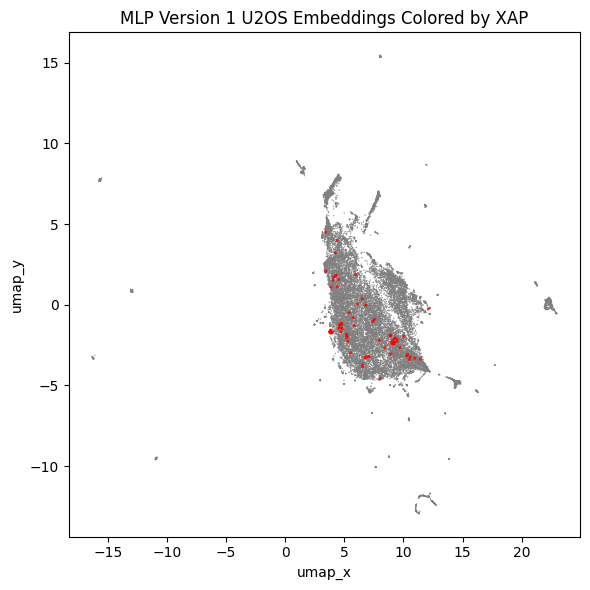

In [79]:
colored = 'XAP'
dataframe = dataframe.sort_values(by=colored)
print(dataframe[colored])
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=dataframe,
    x="umap_x", # may need to change to 'x'
    y="umap_y", # may need to change to 'y'
    hue=colored,
    # hue="loc",
    palette=["gray", "red"],
    # palette=["pink", "orange", "yellow", "gray", "red", "magenta", "purple"],
    size=colored,
    sizes={'XAPs':5, 'Other Proteins':1}, # 20, 5 OR 5, 1
    # sizes={'all three':10, 'dermatomyositis':10, 'dermatomyositis & systemic sclerosis':10, 'none':1, 'systemic lupus erythematosus':10, 'systemic sclerosis':10, 'systemic sclerosis & systemic lupus erythematosus':10}, # 20, 5 OR 5, 1
    # s=2,
    alpha=0.8,
    linewidth=0
)

plt.title(f"MLP Version {version} U2OS Embeddings Colored by {colored}")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.gca().get_legend().remove() # remove ugly legends
plt.tight_layout()
plt.show()

#### Assees XAP clustering

In [31]:
# STORE data for both XAP and UMAP analysis
mlp = mean_mlpv8_u2OS
version = 8

mlp_df = mlp.obs
print(mlp_df.columns)
mlp_data_for_analysis = (mlp.X, mlp_df)

torch.save(mlp_data_for_analysis, f'mlp_data_v{version}_mean_u2os_only.pth')
print('torch saved')
mlp.write_h5ad(f'/scratch/users/samutiti/U54/SubCellNuc/training_V0{version}/inference_U2OS_mean.h5ad')

Index(['gene', 'loc'], dtype='object')
torch saved


In [83]:
! python /scratch/users/samutiti/U54/SubCellNuc/eval/assess_disease_in_embeddings.py u2os_data.pth 'systemic sclerosis'

### Assess systemic sclerosis in Embeddings
Total samples: 12039
Disease samples: 122
Non-Disease samples: 11917

Computing similarities without full matrix...
